In [1]:
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F
import torch

/home/sudip/Desktop/someMLworks/GNN/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = TUDataset(root='/tmp/MUTAG', name='MUTAG')

Processing...
Done!


In [3]:
class MUTAGNet(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(MUTAGNet, self).__init__()
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, dataset.num_classes)
    
    def forward(self, x, edge_index, batch):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index)
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=0.5, training=self.training)
        return self.lin(x)

In [11]:
data = dataset[0]

print(data)

Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])


## Description of inputs

Each data is represented in the form of tensors where:

data.x represents the node features. [17, 7] means this molecule has 17 atoms, and each atom has 7 characteristic features (one-hot encoded atom types).

data.edge_index represents the connectivity. [2, 38] means there are 38 directed edges (19 physical bonds, as bonds are usually stored in both direction)

data.y represents the label, where [1] means this is the ground truth (0 or 1).

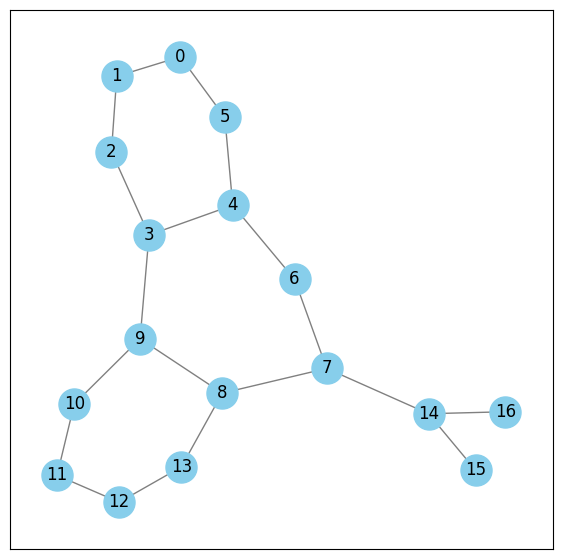

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

def visualize_molecule(data):
    # Convert the PyG data object to a NetworkX graph
    G = to_networkx(data, to_undirected=True)
    
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])
    
    # Draw the graph
    nx.draw_networkx(G, 
                     pos=nx.spring_layout(G, seed=42), 
                     with_labels=True,
                     node_color='skyblue',
                     node_size=500,
                     edge_color='gray')
    plt.show()

# Visualize the first molecule
visualize_molecule(dataset[0])

In [ ]:
def main():
    print("Hello from gnn!")
    global dataset
    dataset = dataset.shuffle()
    train_loader = DataLoader(dataset[:150], batch_size=32, shuffle=True)
    test_loader = DataLoader(dataset[150:], batch_size=32, shuffle=False)

    model = MUTAGNet(hidden_channels=64)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = torch.nn.CrossEntropyLoss()

    def train():
        model.train()
        for data in train_loader:
            optimizer.zero_grad()
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            loss.backward()
            optimizer.step()
    
    def test(loader):
        model.eval()
        correct = 0
        for data in loader:
            out = model(data.x, data.edge_index, data.batch)
            pred = out.argmax(dim=1)
            correct += int((pred == data.y).sum())
        return correct / len(loader.dataset)
    
    def visualize_predictions(model, loader):
        model.eval()
        data = next(iter(loader)) 
        
        with torch.no_grad():
            out = model(data.x, data.edge_index, data.batch)
            probs = F.softmax(out, dim=1)
            predictions = probs.argmax(dim=1)

        print(f"\n--- Prediction Results (First 5 Molecules) ---")
        for i in range(5):
            actual = "Mutagenic" if data.y[i] == 1 else "Non-mutagenic"
            pred_label = "Mutagenic" if predictions[i] == 1 else "Non-mutagenic"
            confidence = probs[i][predictions[i]] * 100
            
            print(f"Molecule {i+1}: Actual: {actual} | Pred: {pred_label} ({confidence:.2f}%)")

    for epoch in range(1, 101):
        train()
        if epoch % 10 == 0:
            train_acc = test(train_loader)
            test_acc = test(test_loader)
            print(f"Epoch: {epoch:03d}, Train acc: {train_acc:.4f}, Test acc: {test_acc:.4f}")
    
    visualize_predictions(model, test_loader)

In [5]:
if __name__ == "__main__":
    main()

Hello from gnn!
Epoch: 010, Train acc: 0.7533, Test acc: 0.7368
Epoch: 020, Train acc: 0.7533, Test acc: 0.7105
Epoch: 030, Train acc: 0.7400, Test acc: 0.7105
Epoch: 040, Train acc: 0.7867, Test acc: 0.6579
Epoch: 050, Train acc: 0.7800, Test acc: 0.6842
Epoch: 060, Train acc: 0.7867, Test acc: 0.6842
Epoch: 070, Train acc: 0.7533, Test acc: 0.6842
Epoch: 080, Train acc: 0.7867, Test acc: 0.6579
Epoch: 090, Train acc: 0.7533, Test acc: 0.6842
Epoch: 100, Train acc: 0.7667, Test acc: 0.7368

--- Prediction Results (First 5 Molecules) ---
Molecule 1: Actual: Mutagenic | Pred: Mutagenic (76.11%)
Molecule 2: Actual: Mutagenic | Pred: Mutagenic (84.08%)
Molecule 3: Actual: Mutagenic | Pred: Mutagenic (78.74%)
Molecule 4: Actual: Mutagenic | Pred: Mutagenic (80.48%)
Molecule 5: Actual: Mutagenic | Pred: Mutagenic (74.86%)


## Description of the Output

The output is either of the class i.e. Mutagenic or Non-Mutagenic. The highest accuracy metric is the output and is represented in terms of percentage of likeliness. The outputs are raw logits in the shape of [batch_size, num_classes], for e.g. [32, 2]. Softmax is applied to turn those scores into percentages that sum to 100%, e.g. [0.1, 0.90], meaning that the model is 90% sure that the molecule is mutagenic.